## Imports & Configuration

In [1]:
# !pip install nltk scikit-learn matplotlib pandas tqdm kagglehub

In [2]:
print('=' * 50)
print("STEP 1.1 — Imports & Configuration \n")

# ── Standard Library ──
import os
import warnings
warnings.filterwarnings('ignore')
import re
import pickle
import string
from collections import Counter
import time

# ── Numerical & Data ──
import numpy as np
import pandas as pd
from tqdm import tqdm   
import kagglehub

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ── Scikit-Learn & NLP ──
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt')

# ── Deep Learning (PyTorch Replaces TensorFlow/Keras) ──
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence





# ── Computer Vision (Torchvision Replaces Keras Applications) ──
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image # Replaces keras load_img

# ── Reproducibility ──
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Set PyTorch seeds
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    
# ── Hardware Check ──
print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == 'cuda':
    print("GPU Name:", torch.cuda.get_device_name(0))

print('=' * 50)

STEP 1.1 — Imports & Configuration 



[nltk_data] Downloading package punkt to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


PyTorch version: 2.8.0+cu128
Using device: cuda
GPU Name: NVIDIA H100 80GB HBM3


## Load & Explore both datasets

In [3]:
print('=' * 50)
print("STEP 2 — Download Load & Combine Both Datasets \n")

print("Downloading datasets...")
path30k = kagglehub.dataset_download("hsankesara/flickr-image-dataset")
print("Path to 30k files:", path30k)

path8k = kagglehub.dataset_download("adityajn105/flickr8k")
print("Path to 8k files:", path8k)


IMAGES_PATH_8K  = f'{path8k}/Images/'
IMAGES_PATH_30K = f'{path30k}/flickr30k_images/flickr30k_images/'
CAPTIONS_8K     = f'{path8k}/captions.txt'
CAPTIONS_30K    = f'{path30k}/flickr30k_images/results.csv'
print('=' * 50)

STEP 2 — Download Load & Combine Both Datasets 

Path to 30k files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1
Path to 8k files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1


In [4]:
# print('=' * 50)
# print("STEP 2 — Load & Combine Both Datasets \n")

# IMAGES_PATH_8K  = '/kaggle/input/datasets/adityajn105/flickr8k/Images/'
# IMAGES_PATH_30K = '/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/flickr30k_images/'
# CAPTIONS_8K     = '/kaggle/input/datasets/adityajn105/flickr8k/captions.txt'
# CAPTIONS_30K    = '/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv'

# ── Load 8k ──
df_8k = pd.read_csv(CAPTIONS_8K)
df_8k.columns = ['image', 'caption']
df_8k['dataset']    = '8k'
df_8k['image_path'] = df_8k['image'].apply(lambda x: os.path.join(IMAGES_PATH_8K, x))

# ── Load 30k ──
df_30k = pd.read_csv(CAPTIONS_30K, sep='|')
df_30k.columns = ['image', 'comment_number', 'caption']   # strip spaces
df_30k          = df_30k[['image', 'caption']].copy()      # drop comment_number
df_30k['image']      = df_30k['image'].str.strip()         # strip whitespace from image names
df_30k['caption']    = df_30k['caption'].str.strip()       # strip whitespace from captions
df_30k['dataset']    = '30k'
df_30k['image_path'] = df_30k['image'].apply(lambda x: os.path.join(IMAGES_PATH_30K, x))

# ── Check ID collision before combining ──
ids_8k  = set(df_8k['image'].unique())
ids_30k = set(df_30k['image'].unique())
overlap = ids_8k & ids_30k
print(f"Overlapping image IDs : {len(overlap)}")

if len(overlap) > 0:
    print("Collision found — adding prefix to image IDs")
    df_8k['image']  = '8k_'  + df_8k['image']
    df_30k['image'] = '30k_' + df_30k['image']
else:
    print("No collision — safe to combine directly ✓")

# ── Combine ──
df = pd.concat([df_8k, df_30k], ignore_index=True)

print(f"\nCombined shape     : {df.shape}")
print(f"Unique images      : {df['image'].nunique()}")
print(f"Dataset breakdown  :")
print(df.groupby('dataset')['image'].nunique())
print(f"\nSample rows:")
display(df.sample(5, random_state=SEED))

print('=' * 50)

Overlapping image IDs : 0
No collision — safe to combine directly ✓

Combined shape     : (199370, 4)
Unique images      : 39874
Dataset breakdown  :
dataset
30k    31783
8k      8091
Name: image, dtype: int64

Sample rows:


,image,caption,dataset,image_path
167407,4941750266.jpg,A person in a cream shirt looking at a body of...,30k,/teamspace/studios/this_studio/.cache/kagglehu...
3954,1925434818_2949a8f6d8.jpg,Two children slide down a slide into a ball pi...,8k,/teamspace/studios/this_studio/.cache/kagglehu...
32849,3621652774_fd9634bd5b.jpg,Baby sitting in blue plastic pool while water ...,8k,/teamspace/studios/this_studio/.cache/kagglehu...
111810,3451360781.jpg,A yard laborer is cutting grass with a push la...,30k,/teamspace/studios/this_studio/.cache/kagglehu...
47396,140738818.jpg,A baby standing up and holding onto a couch fo...,30k,/teamspace/studios/this_studio/.cache/kagglehu...


## Caption Preprocessing & Vocabulary

In [5]:
print('=' * 50)
print("STEP 3 — Clean Captions \n")


def clean_caption(caption):
    # 1. Lowercase and strip leading/trailing whitespace
    caption = str(caption).lower().strip()
    
    # 2. Remove extra spaces
    caption = re.sub(r'\s+', ' ', caption)
    
    # 3. Remove non-ascii characters
    caption = caption.encode('ascii', errors='ignore').decode()
    
    # 4. Remove punctuation
    caption = caption.translate(str.maketrans('', '', string.punctuation))
    
    # 5. Remove single-character words (except 'a')
    caption = ' '.join([w for w in caption.split() if len(w) > 1 or w == 'a'])
    
    # 6. Add start and end tokens (Crucial for Sequence-to-Sequence models)
    caption = '<start> ' + caption + ' <end>'
    
    return caption

# Apply the cleaning function to the entire dataframe
df['caption'] = df['caption'].apply(clean_caption)

# Drop exact duplicates (same image and same exact caption)
df = df.drop_duplicates(subset=['image', 'caption']).reset_index(drop=True)

print(f"After cleaning & dropping duplicates: {df.shape}")
print(f"\nSample cleaned captions:")
for cap in df['caption'].sample(5, random_state=SEED).tolist():
    print("-", cap)

print('=' * 50)

STEP 3 — Clean Captions 

After cleaning & dropping duplicates: (199304, 4)

Sample cleaned captions:
- <start> a black and brown dog in a grassy welllit area with his mouth partially open <end>
- <start> three members of a band are all practicing their different instrument skills <end>
- <start> a quarterback scans the football field while the offensive line protects him <end>
- <start> a man extends his arms in front of a large rock formation <end>
- <start> a blond man jumping off a cliff into some water <end>


In [6]:
print('=' * 50)
print("STEP 4.1 — Build image → captions mapping \n")

captions_dict = {}
image_to_path = {}

for _, row in df.iterrows():
    img_id = row['image']
    if img_id not in captions_dict:
        captions_dict[img_id]  = []
        image_to_path[img_id]  = row['image_path']
    captions_dict[img_id].append(row['caption'])

print(f"Unique images in dict : {len(captions_dict)}")

# ── Build vocabulary ──
word_counter = Counter()
for captions in captions_dict.values():
    for caption in captions:
        word_counter.update(caption.split())

print(f"Vocabulary size before frequency filtering: {len(word_counter)}")

print('=' * 50)

STEP 4.1 — Build image → captions mapping 

Unique images in dict : 39874
Vocabulary size before frequency filtering: 20028


STEP 4.2 — Find the right FREQ_THRESHOLD 



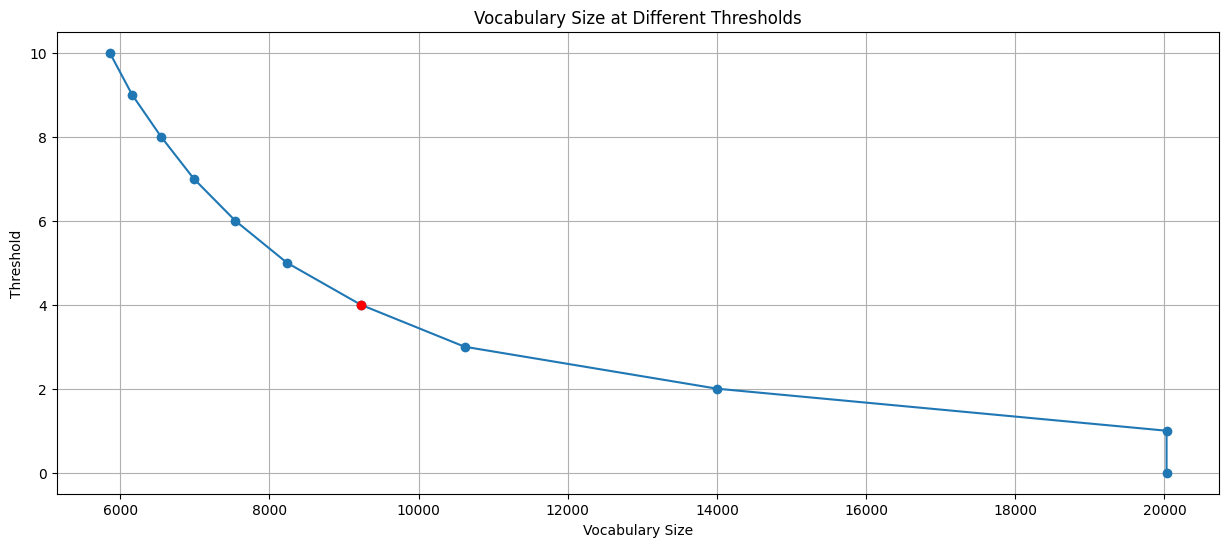

In [7]:
print('=' * 50)
print("STEP 4.2 — Find the right FREQ_THRESHOLD \n")

thresholds = range(11)
vocab_sizes = []

# Calculate vocabulary size for each threshold
for t in thresholds:
    vocab_at_threshold = [
        w for w, c in word_counter.items()
        if c >= t
    ]
    vocab_sizes.append(len(vocab_at_threshold))

# Create the plot
plt.figure(figsize=(15, 6))
plt.plot(vocab_sizes, thresholds, marker='o', linestyle='-')
plt.plot(vocab_sizes[4], 4, 'ro')
# Add labels and title
plt.xlabel('Vocabulary Size')
plt.ylabel('Threshold')
plt.title('Vocabulary Size at Different Thresholds')
plt.grid(True)

print('=' * 50)

STEP 4.3 — Find the right MAX_LEN 

90th percentile : 20 tokens
95th percentile : 23 tokens
98th percentile : 27 tokens
99th percentile : 30 tokens
100th percentile : 80 tokens


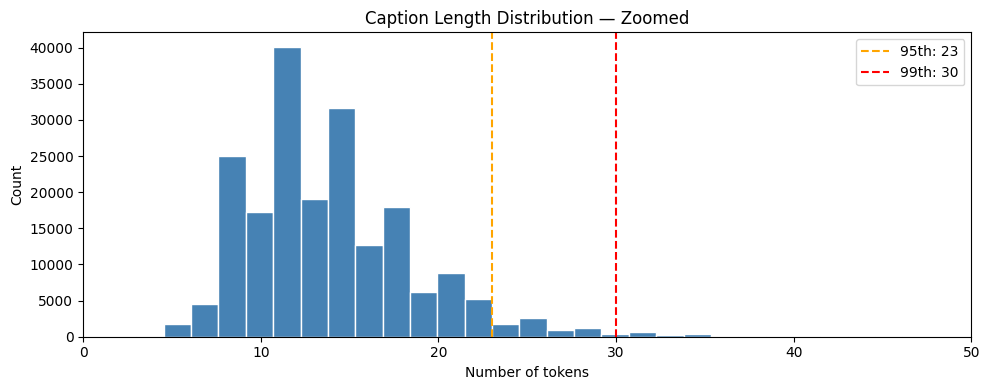

In [8]:
print('=' * 50)
print("STEP 4.3 — Find the right MAX_LEN \n")

all_lengths = [
    len(cap.split())
    for caps in captions_dict.values()
    for cap in caps
]

for pct in [90, 95, 98, 99, 100]:
    print(f"{pct}th percentile : {np.percentile(all_lengths, pct):.0f} tokens")


# Plot with better view
plt.figure(figsize=(10, 4))
plt.hist(all_lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.percentile(all_lengths, 95), color='orange', linestyle='--', label='95th: ' + str(int(np.percentile(all_lengths, 95))))
plt.axvline(np.percentile(all_lengths, 99), color='red',    linestyle='--', label='99th: ' + str(int(np.percentile(all_lengths, 99))))
plt.xlim(0, 50)          # zoom in — ignore extreme outliers beyond 50
plt.title('Caption Length Distribution — Zoomed')
plt.xlabel('Number of tokens')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print('=' * 50)

In [9]:
print('=' * 50)
print("STEP 4.4 — Build Vocabulary & Mappings \n")

FREQ_THRESHOLD = 4
MAX_LEN = 30

# Define special tokens used for sequence padding and unknown words
special_tokens = ['<pad>', '<start>', '<end>', '<unk>']

# Filter words by frequency to reduce noise, then combine with special tokens
vocab = special_tokens + sorted([
    w for w, c in word_counter.items()
    if c >= FREQ_THRESHOLD and w not in special_tokens
])

# Create the final mapping dictionaries
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

VOCAB_SIZE = len(vocab)
print(f"Vocabulary size after filtering: {VOCAB_SIZE}")

print('=' * 50)

STEP 4.4 — Build Vocabulary & Mappings 

Vocabulary size after filtering: 9227


## Train / Val / Test Split

In [10]:
print('=' * 50)
print("STEP 5 — Train, Validation, & Test Splits \n")

# Get unique image IDs
unique_images = df['image'].unique()

# Split: 80% train, 20% temp (which becomes 10% val, 10% test)
train_imgs, temp_imgs = train_test_split(
    unique_images,
    test_size=0.20,
    random_state=SEED
)

# Split temp into val and test
val_imgs, test_imgs = train_test_split(
    temp_imgs,
    test_size=0.50,
    random_state=SEED
)

print(f"Train images : {len(train_imgs)}")
print(f"Val images   : {len(val_imgs)}")
print(f"Test images  : {len(test_imgs)}")

# Sanity check – ensuring strict isolation between sets
assert len(set(train_imgs) & set(val_imgs))  == 0
assert len(set(train_imgs) & set(test_imgs)) == 0
assert len(set(val_imgs)   & set(test_imgs)) == 0
print("Sanity check passed: No overlap between splits ✓")

print('=' * 50)

STEP 5 — Train, Validation, & Test Splits 

Train images : 31899
Val images   : 3987
Test images  : 3988
Sanity check passed: No overlap between splits ✓


## Save all preprocessing outputs

In [11]:
print('=' * 50)
print("STEP 6 — Save Preprocessing Artifacts \n")

# Save the vocabulary mappings
with open('word2idx.pkl',      'wb') as f: pickle.dump(word2idx, f)
with open('idx2word.pkl',      'wb') as f: pickle.dump(idx2word, f)

# Save the dataset dictionaries
with open('captions_dict.pkl', 'wb') as f: pickle.dump(captions_dict, f)
with open('image_to_path.pkl', 'wb') as f: pickle.dump(image_to_path, f)

# Save the dataset splits to ensure consistent evaluation later
with open('train_imgs.pkl',    'wb') as f: pickle.dump(train_imgs, f)
with open('val_imgs.pkl',      'wb') as f: pickle.dump(val_imgs, f)
with open('test_imgs.pkl',     'wb') as f: pickle.dump(test_imgs, f)

print(f"VOCAB_SIZE saved : {VOCAB_SIZE}")
print(f"MAX_LEN saved    : {MAX_LEN}")
print("All artifacts successfully saved to disk ✓")

print('=' * 50)

STEP 6 — Save Preprocessing Artifacts 

VOCAB_SIZE saved : 9227
MAX_LEN saved    : 30
All artifacts successfully saved to disk ✓


## EfficientNetB3 Spatial Feature Extraction

In [12]:
print('=' * 50)
print("STEP 5 — Images Feature Extraction Pipeline \n")

class CNNEncoder(nn.Module):
    def __init__(self, fine_tune=True):
        super(CNNEncoder, self).__init__()
        
        # Load pre-trained EfficientNetB3
        print("Loading EfficientNetB3...")
        base_model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.extractor = base_model.features
        
        # 1. First, freeze the ENTIRE network
        for param in self.extractor.parameters():
            param.requires_grad = False
            
        # 2. Unfreeze only the final few blocks if fine_tune is True
        if fine_tune:
            print("Unfreezing the top layers of EfficientNetB3...")
            # EfficientNet features are stored in an iterable.
            # We skip the first 6 blocks and only unfreeze block 6, 7, and 8.
            for block in list(self.extractor.children())[6:]:
                for param in block.parameters():
                    param.requires_grad = True

    def forward(self, images):
        # Forward pass
        features = self.extractor(images)
        
        # Reshape from (Batch, 1536, 10, 10) to (Batch, 100, 1536)
        features = features.view(features.size(0), features.size(1), -1).permute(0, 2, 1)
        return features

# Instantiate it
print("Initiating Encoder...")
encoder = CNNEncoder(fine_tune=True).to(device)


print('=' * 50)

STEP 5 — Images Feature Extraction Pipeline 

Initiating Encoder...
Loading EfficientNetB3...
Unfreezing the top layers of EfficientNetB3...


## Data Generator

In [13]:
print('=' * 50)
print("STEP 8 — The PyTorch Data Generator \n")


class FineTuningCaptionDataset(Dataset):
    def __init__(self, img_keys, captions_dict, word2idx, image_to_path, max_len=30):
        self.image_to_path = image_to_path
        self.word2idx = word2idx
        self.max_len = max_len
        self.pad_idx = word2idx['<pad>']
        
        # Exact preprocessing expected by EfficientNet
        self.transform = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # Flatten the data: 1 sample = (1 image, 1 caption)
        self.data = []
        for img_id in img_keys:
            for cap in captions_dict[img_id]:
                self.data.append((img_id, cap))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id, caption_text = self.data[idx]

        # ── IMAGE PROCESSING ──
        img_path = self.image_to_path[img_id]
        image = Image.open(img_path).convert('RGB') 
        image_tensor = self.transform(image)

        # ── TEXT PROCESSING ──
        tokens = caption_text.split()
        seq = [self.word2idx.get(w, self.word2idx['<unk>']) for w in tokens]
        
        seq = seq[:self.max_len]
        padded_seq = seq + [self.pad_idx] * (self.max_len - len(seq))
        
        # Shift inputs and targets
        input_seq = padded_seq[:-1]
        target_seq = padded_seq[1:]

        return image_tensor, torch.tensor(input_seq), torch.tensor(target_seq)


# ─────────────────────────────────────────────
# 3. Instantiate the DataLoaders
# ─────────────────────────────────────────────
print("Building DataLoaders...")

train_dataset = FineTuningCaptionDataset(train_imgs, captions_dict, word2idx, image_to_path, MAX_LEN)
val_dataset   = FineTuningCaptionDataset(val_imgs,   captions_dict, word2idx, image_to_path, MAX_LEN)
test_dataset  = FineTuningCaptionDataset(test_imgs,  captions_dict, word2idx, image_to_path, MAX_LEN)

# num_workers=4 uses your CPU cores to load images in the background while the GPU trains
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print('=' * 50)

STEP 8 — The PyTorch Data Generator 

Building DataLoaders...
Train batches: 2492 | Val batches: 312


In [14]:
print('=' * 50)
print("STEP 9 — Pre-trained GloVe Embeddings \n")


# 1. Download and Unzip (Only runs if the file doesn't exist yet)
if not os.path.exists('glove.6B.300d.txt'):
    print("Downloading GloVe embeddings...")
    # 1. Download the full zip
    !wget http://nlp.stanford.edu/data/glove.6B.zip
    
    # 2. Extract ONLY the 300-dimension file
    !unzip glove.6B.zip glove.6B.300d.txt
    
    # 3. Delete the heavy zip file to save disk space
    !rm glove.6B.zip
else:
    print("GloVe embeddings already downloaded.")

# 2. Build the Matrix (Your exact logic, slightly cleaned up)
def load_glove_embeddings(glove_path, word2idx, embed_dim):
    embeddings_index = {}
    with open(glove_path, 'r', encoding='utf8') as f:
        for line in tqdm(f, desc='Loading GloVe into memory'):
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    # Initialize matrix with random values (for words not in GloVe, like <start> or <unk>)
    embedding_matrix = np.random.normal(scale=0.6, size=(len(word2idx), embed_dim))
    
    # ── PyTorch Best Practice: Zero the Pad Token ──
    # We explicitly zero out the padding token so it doesn't contribute to gradients
    pad_idx = word2idx['<pad>']
    embedding_matrix[pad_idx] = np.zeros(embed_dim)

    hits = 0
    for word, idx in word2idx.items():
        vector = embeddings_index.get(word)
        if vector is not None:
            embedding_matrix[idx] = vector
            hits += 1
            
    print(f'Found {hits} out of {len(word2idx)} words in GloVe.')
    return embedding_matrix

# Execute the function
EMBED_DIM = 300
embedding_matrix = load_glove_embeddings('glove.6B.300d.txt', word2idx, embed_dim=EMBED_DIM)

# 3. ── The PyTorch Translation ──
# Convert the NumPy array to a PyTorch FloatTensor
embedding_tensor = torch.FloatTensor(embedding_matrix)

# Create the PyTorch Embedding Layer
# By setting freeze=False, we tell PyTorch to update these weights during backpropagation (Trainable!)
# padding_idx tells PyTorch to completely ignore the <pad> token during training
embedding_layer = nn.Embedding.from_pretrained(
    embedding_tensor, 
    freeze=False, 
    padding_idx=word2idx['<pad>']
)

print("\nPyTorch Embedding Layer created successfully!")
print(f"Trainable Parameters: {embedding_layer.weight.requires_grad}") # Should print True

print('=' * 50)

STEP 9 — Pre-trained GloVe Embeddings 

GloVe embeddings already downloaded.


Loading GloVe into memory: 400000it [00:15, 25587.19it/s]


Found 8961 out of 9227 words in GloVe.

PyTorch Embedding Layer created successfully!
Trainable Parameters: True


## Attention Model Layer

In [ ]:
print('=' * 50)
print("STEP 10 — The LSTM+Attention Model Architecture \n")


class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(BahdanauAttention, self).__init__()
        # W1 transforms the image features
        self.W1 = nn.Linear(encoder_dim, attention_dim)
        # W2 transforms the hidden state of the decoder
        self.W2 = nn.Linear(decoder_dim, attention_dim)
        # V calculates the final score
        self.V = nn.Linear(attention_dim, 1)

    def forward(self, features, hidden_state):
        # features shape: (batch_size, num_pixels, encoder_dim)  -> e.g., (128, 100, 1536)
        # hidden_state shape: (batch_size, decoder_dim) -> e.g., (128, 512)

        # Expand hidden state to match features dimension: (batch_size, 1, decoder_dim)
        hidden_expanded = hidden_state.unsqueeze(1)
        
        # Calculate attention scores
        # shape: (batch_size, num_pixels, attention_dim)
        attention_hidden = torch.tanh(self.W1(features) + self.W2(hidden_expanded))
        
        # shape: (batch_size, num_pixels, 1)
        score = self.V(attention_hidden)
        
        # Calculate softmax weights over the pixels
        # shape: (batch_size, num_pixels, 1)
        attention_weights = F.softmax(score, dim=1)
        
        # Multiply weights by features and sum over pixels to get context vector
        # shape: (batch_size, encoder_dim)
        context_vector = attention_weights * features
        context_vector = torch.sum(context_vector, dim=1)
        
        return context_vector, attention_weights


class ImageCaptioningModel(nn.Module):
    
    def __init__(self, vocab_size, embed_dim, encoder_dim, decoder_dim, attention_dim, embedding_tensor=None):
        super(ImageCaptioningModel, self).__init__()
        
        self.vocab_size = vocab_size
        self.encoder_dim = encoder_dim
        self.decoder_dim = decoder_dim
        
        # 1. Embedding Layer
        if embedding_tensor is not None:
            self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=False, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            
        # 2. Attention Module
        self.attention = BahdanauAttention(encoder_dim, decoder_dim, attention_dim)
        
        # 3. LSTM Cell
        # Notice we use LSTMCell instead of LSTM. This allows us to step through 
        # the sequence word-by-word manually to apply attention at each step.
        # Input to LSTM is the embedding + the context vector from the image
        # 3. Stacked LSTM Cells
        # First LSTM looks at the word + image context
        self.lstm_cell_1 = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim, bias=True)
        
        # Second LSTM looks at the output of the first LSTM
        self.lstm_cell_2 = nn.LSTMCell(decoder_dim, decoder_dim, bias=True)
        
        # Dropout between layers (Just like your TF code!)
        self.dropout_lstm = nn.Dropout(0.5)  # between LSTM 1 → LSTM 2

        # 4. Final output layers
        self.dropout_out  = nn.Dropout(0.5)  # before final fc layer
        self.fc = nn.Linear(decoder_dim, vocab_size)

    def forward(self, features, captions):
        batch_size = features.size(0)
        seq_length = captions.size(1)
        
        embeddings = self.embedding(captions)
        
        # Initialize hidden states for BOTH LSTMs
        h1 = torch.zeros((batch_size, self.decoder_dim)).to(features.device)
        c1 = torch.zeros((batch_size, self.decoder_dim)).to(features.device)
        
        h2 = torch.zeros((batch_size, self.decoder_dim)).to(features.device)
        c2 = torch.zeros((batch_size, self.decoder_dim)).to(features.device)
        
        predictions = torch.zeros(batch_size, seq_length, self.vocab_size).to(features.device)
        
        # ── The Time-Step Loop ──
        for t in range(seq_length):
            # 1. Attention uses the hidden state of the SECOND LSTM
            context_vector, attention_weights = self.attention(features, h2)
            
            # 2. Input for the first LSTM
            lstm_input = torch.cat([embeddings[:, t, :], context_vector], dim=1)
            
            # 3. Pass through First LSTM
            h1, c1 = self.lstm_cell_1(lstm_input, (h1, c1))
            
            # 4. Apply Dropout between LSTMs
            h1_drop = self.dropout_lstm(h1)
            
            # 5. Pass through Second LSTM
            h2, c2 = self.lstm_cell_2(h1_drop, (h2, c2))
            
            # 6. Final prediction using the second LSTM's output
            output = self.fc(self.dropout_out(h2))
            
            predictions[:, t, :] = output
            
        return predictions

# ── Instantiate the Model ──
# Note: You can adjust these dimensions based on your previous config
ENCODER_DIM = 1536 # Output from EfficientNet
DECODER_DIM = 512  # Number of LSTM units
ATTENTION_DIM = 256 # Size of attention projection space

model = ImageCaptioningModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    encoder_dim=ENCODER_DIM,
    decoder_dim=DECODER_DIM,
    attention_dim=ATTENTION_DIM,
    embedding_tensor=embedding_tensor # Pass in the GloVe tensor we built
)

model = model.to(device) # Move model to L40S GPU
print(model)

print('=' * 50)

STEP 10 — The LSTM+Attention Model Architecture 

ImageCaptioningModel(
  (embedding): Embedding(9227, 300, padding_idx=0)
  (attention): BahdanauAttention(
    (W1): Linear(in_features=1536, out_features=256, bias=True)
    (W2): Linear(in_features=512, out_features=256, bias=True)
    (V): Linear(in_features=256, out_features=1, bias=True)
  )
  (lstm_cell_1): LSTMCell(1836, 512)
  (lstm_cell_2): LSTMCell(512, 512)
  (dropout_lstm): Dropout(p=0.5, inplace=False)
  (dropout_out): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=9227, bias=True)
)


## Compile & Train Baseline Model

In [ ]:
print('=' * 50)
print("STEP 11 — Optimizer, Loss, and Training Loop \n")

print("Setting up Fine-Tuning Training Loop...\n")

# 1. Define Loss Function
pad_idx = word2idx['<pad>']
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

# 2. DIFFERENTIAL LEARNING RATES
# 1. Grab CNN parameters (Pre-trained)
encoder_params = [p for p in encoder.parameters() if p.requires_grad]

# 2. Grab GloVe Embedding parameters (Pre-trained)
embedding_params = [p for p in model.embedding.parameters() if p.requires_grad]

# 3. Grab LSTM/Attention/FC parameters (Randomly Initialized)
# We have to explicitly filter OUT the embedding weights so they don't get mixed in here
embedding_ids = set(id(p) for p in model.embedding.parameters())
decoder_scratch_params = [
    p for p in model.parameters() 
    if id(p) not in embedding_ids and p.requires_grad
]

# 4. Create the 3-Tiered Optimizer
optimizer = optim.Adam([
    {'params': decoder_scratch_params, 'lr': 3e-4}, # Fast: LSTM/Attention starting from scratch
    {'params': embedding_params,       'lr': 1e-5}, # Slow: Protects GloVe semantic relationships
    {'params': encoder_params,         'lr': 1e-5}  # Slow: Protects EfficientNet visual features
], weight_decay=1e-4)

# 3. Scheduler & Tracking
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.4, patience=3, min_lr=1e-6)

EPOCHS = 50
CLIP = 1.0
patience = 8
patience_counter = 0
best_val_loss = float('inf')

train_loss_history = []
val_loss_history = []

print("Starting Fine-Tuning Training...")

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # ─────────────────────────────────────────────
    # TRAINING PHASE
    # ─────────────────────────────────────────────
    model.train()
    encoder.train() 
    train_loss = 0
    
    # Wrap the train_loader
    for batch_idx, (images, inputs, targets) in enumerate(train_loader):

        images = images.to(device)
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        
        img_feats = encoder(images)
        outputs = model(img_feats, inputs)
        
        outputs_flat = outputs.view(-1, VOCAB_SIZE)
        targets_flat = targets.view(-1)
        
        loss = criterion(outputs_flat, targets_flat)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + list(encoder.parameters()), CLIP)
        
        optimizer.step()
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    
    # ─────────────────────────────────────────────
    # VALIDATION PHASE
    # ─────────────────────────────────────────────
    model.eval()
    encoder.eval()
    val_loss = 0
    
    # Wrap the val_loader

    with torch.no_grad():
        for images, inputs, targets in val_loader:
            images = images.to(device)
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            img_feats = encoder(images)
            outputs = model(img_feats, inputs)
            
            outputs_flat = outputs.view(-1, VOCAB_SIZE)
            targets_flat = targets.view(-1)
            
            loss = criterion(outputs_flat, targets_flat)
            val_loss += loss.item()
            

            
    avg_val_loss = val_loss / len(val_loader)
    
    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)
    
    scheduler.step(avg_val_loss)
    
    # ─────────────────────────────────────────────
    # EPOCH SUMMARY
    # ─────────────────────────────────────────────
    current_lr_decoder = optimizer.param_groups[0]['lr']
    current_lr_glove = optimizer.param_groups[1]['lr']
    current_lr_encoder = optimizer.param_groups[2]['lr']
    epoch_mins = (time.time() - start_time) / 60
    
    # Clear the tqdm line and print the permanent summary for the epoch
    print(f'\nEpoch: {epoch+1:02} | Time: {epoch_mins:.2f}m')
    print(f'\tLR (LSTM): {current_lr_decoder} | LR (GLOVE): {current_lr_glove} | LR (CNN): {current_lr_encoder}')
    print(f'\tTrain Loss: {avg_train_loss:.4f} | Val. Loss: {avg_val_loss:.4f}')
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        
        torch.save(model.state_dict(), 'best_model.pth')
        torch.save(encoder.state_dict(), 'best_encoder.pth')
        print(f'\t*** Validation loss decreased. Saved new best weights! ***\n')
    else:
        patience_counter += 1
        print(f'\t--- No improvement in validation loss. Patience: {patience_counter}/{patience} ---\n')
        if patience_counter >= patience:
            print(f"Early stopping triggered! Training complete.")
            break

    
    # if (epoch + 1) % 2 == 0:
    #     b1, b2, b3, b4 = evaluate_bleu(
    #         model, val_imgs, val_feats, captions_dict,
    #         word2idx, idx2word, MAX_LEN, num_samples=300
    #     )
    #     bleu4_history.append(b4)
    #     # Also checkpoint on best BLEU-4 instead of just val loss
    #     if b4 > best_bleu4:
    #         best_bleu4 = b4
    #         torch.save(model.state_dict(), 'best_model_bleu.pth')
    #         print(f'\t*** New best BLEU-4: {b4:.4f}. Saved best_model_bleu.pth ***')

print('=' * 50)

================================================== 

STEP 11 — Optimizer, Loss, and Training Loop 

Setting up Fine-Tuning Training Loop... 

Starting Fine-Tuning Training...

Epoch: 01 | Time: 4.84m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 4.2108 | Val. Loss: 3.5629 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 01 | Time: 4.84m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 4.2108 | Val. Loss: 3.5629 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 02 | Time: 4.82m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.5412 | Val. Loss: 3.3101 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 03 | Time: 4.84m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.3676 | Val. Loss: 3.1933 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 04 | Time: 4.87m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.2738 | Val. Loss: 3.1251
 *** Validation loss decreased. Saved new best weights! ***

Epoch: 05 | Time: 4.85m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.2129 | Val. Loss: 3.0815 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 06 | Time: 4.85m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.1707 | Val. Loss: 3.0506 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 07 | Time: 4.84m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.1378 | Val. Loss: 3.0263 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 08 | Time: 4.86m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.1118 | Val. Loss: 3.0127 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 09 | Time: 4.85m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.0890 | Val. Loss: 2.9946 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 10 | Time: 5.55m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.0715 | Val. Loss: 2.9879 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 11 | Time: 4.87m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.0565 | Val. Loss: 2.9816 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 12 | Time: 4.88m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.0432 | Val. Loss: 2.9718 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 13 | Time: 4.85m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.0318 | Val. Loss: 2.9629 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 14 | Time: 4.88m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.0209 | Val. Loss: 2.9581 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 15 | Time: 4.87m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.0120 | Val. Loss: 2.9613 
--- No improvement in validation loss. Patience: 1/8 ---

Epoch: 16 | Time: 4.85m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 3.0036 | Val. Loss: 2.9563 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 17 | Time: 4.87m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 2.9961 | Val. Loss: 2.9482 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 18 | Time: 4.86m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 2.9886 | Val. Loss: 2.9469 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 19 | Time: 4.88m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 2.9824 | Val. Loss: 2.9504 
--- No improvement in validation loss. Patience: 1/8 ---

Epoch: 20 | Time: 4.84m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 2.9765 | Val. Loss: 2.9428 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 21 | Time: 4.87m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 2.9708 | Val. Loss: 2.9450 
--- No improvement in validation loss. Patience: 1/8 ---

Epoch: 22 | Time: 4.84m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 2.9667 | Val. Loss: 2.9425 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 23 | Time: 4.88m LR (LSTM): 0.0003 | LR (CNN): 1e-05 Train Loss: 2.9619 | Val. Loss: 2.9506 
--- No improvement in validation loss. Patience: 1/8 ---

Epoch: 24 | Time: 4.84m LR (LSTM): 0.00011999999999999999 | LR (CNN): 4.000000000000001e-06 Train Loss: 2.9583 | Val. Loss: 2.9425 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 25 | Time: 4.88m LR (LSTM): 0.00011999999999999999 | LR (CNN): 4.000000000000001e-06 Train Loss: 2.9039 | Val. Loss: 2.9132 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 26 | Time: 4.85m LR (LSTM): 0.00011999999999999999 | LR (CNN): 4.000000000000001e-06 Train Loss: 2.8941 | Val. Loss: 2.9169 
--- No improvement in validation loss. Patience: 1/8 ---

Epoch: 27 | Time: 4.86m LR (LSTM): 0.00011999999999999999 | LR (CNN): 4.000000000000001e-06 Train Loss: 2.8924 | Val. Loss: 2.9150 
--- No improvement in validation loss. Patience: 2/8 ---

Epoch: 28 | Time: 4.87m LR (LSTM): 0.00011999999999999999 | LR (CNN): 4.000000000000001e-06 Train Loss: 2.8907 | Val. Loss: 2.9219 
--- No improvement in validation loss. Patience: 3/8 ---

Epoch: 29 | Time: 4.88m LR (LSTM): 4.8e-05 | LR (CNN): 1.6000000000000004e-06 Train Loss: 2.8894 | Val. Loss: 2.9233 
--- No improvement in validation loss. Patience: 4/8 ---

Epoch: 30 | Time: 4.86m LR (LSTM): 4.8e-05 | LR (CNN): 1.6000000000000004e-06 Train Loss: 2.8638 | Val. Loss: 2.9120 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 31 | Time: 4.85m LR (LSTM): 4.8e-05 | LR (CNN): 1.6000000000000004e-06 Train Loss: 2.8599 | Val. Loss: 2.9119 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 32 | Time: 4.88m LR (LSTM): 4.8e-05 | LR (CNN): 1.6000000000000004e-06 Train Loss: 2.8583 | Val. Loss: 2.9130 
--- No improvement in validation loss. Patience: 1/8 ---

Epoch: 33 | Time: 4.86m LR (LSTM): 4.8e-05 | LR (CNN): 1.6000000000000004e-06 Train Loss: 2.8587 | Val. Loss: 2.9135 
--- No improvement in validation loss. Patience: 2/8 ---

Epoch: 34 | Time: 4.84m LR (LSTM): 1.9200000000000003e-05 | LR (CNN): 1e-06 Train Loss: 2.8580 | Val. Loss: 2.9155 
--- No improvement in validation loss. Patience: 3/8 ---

Epoch: 35 | Time: 4.84m LR (LSTM): 1.9200000000000003e-05 | LR (CNN): 1e-06 Train Loss: 2.8472 | Val. Loss: 2.9118 
*** Validation loss decreased. Saved new best weights! ***

Epoch: 36 | Time: 4.88m LR (LSTM): 1.9200000000000003e-05 | LR (CNN): 1e-06 Train Loss: 2.8452 | Val. Loss: 2.9132 
--- No improvement in validation loss. Patience: 1/8 ---

Epoch: 37 | Time: 4.85m LR (LSTM): 1.9200000000000003e-05 | LR (CNN): 1e-06 Train Loss: 2.8452 | Val. Loss: 2.9136 
--- No improvement in validation loss. Patience: 2/8 ---

Epoch: 38 | Time: 4.85m LR (LSTM): 7.680000000000001e-06 | LR (CNN): 1e-06 Train Loss: 2.8442 | Val. Loss: 2.9137 
--- No improvement in validation loss. Patience: 3/8 ---

Epoch: 39 | Time: 5.24m LR (LSTM): 7.680000000000001e-06 | LR (CNN): 1e-06 Train Loss: 2.8389 | Val. Loss: 2.9134 
--- No improvement in validation loss. Patience: 4/8 ---

Epoch: 40 | Time: 4.86m LR (LSTM): 7.680000000000001e-06 | LR (CNN): 1e-06 Train Loss: 2.8388 | Val. Loss: 2.9139 
--- No improvement in validation loss. Patience: 5/8 ---

Epoch: 41 | Time: 4.87m LR (LSTM): 7.680000000000001e-06 | LR (CNN): 1e-06 Train Loss: 2.8379 | Val. Loss: 2.9139 
--- No improvement in validation loss. Patience: 6/8 ---

Epoch: 42 | Time: 4.85m LR (LSTM): 3.0720000000000004e-06 | LR (CNN): 1e-06 Train Loss: 2.8373 | Val. Loss: 2.9144 
--- No improvement in validation loss. Patience: 7/8 ---

Epoch: 43 | Time: 4.86m LR (LSTM): 3.0720000000000004e-06 | LR (CNN): 1e-06 Train Loss: 2.8353 | Val. Loss: 2.9140 
--- No improvement in validation loss. Patience: 8/8 

--- Early stopping triggered! Training complete. 

==================================================



## Evaluation

In [18]:
train_loss_history = [
    4.2108, 3.5412, 3.3676, 3.2738, 3.2129, 3.1707, 3.1378, 3.1118, 3.0890, 
    3.0715, 3.0565, 3.0432, 3.0318, 3.0209, 3.0120, 3.0036, 2.9961, 2.9886, 
    2.9824, 2.9765, 2.9708, 2.9667, 2.9619, 2.9583, 2.9039, 2.8941, 2.8924, 
    2.8907, 2.8894, 2.8638, 2.8599, 2.8583, 2.8587, 2.8580, 2.8472, 2.8452, 
    2.8452, 2.8442, 2.8389, 2.8388, 2.8379, 2.8373, 2.8353
]

val_loss_history = [
    3.5629, 3.3101, 3.1933, 3.1251, 3.0815, 3.0506, 3.0263, 3.0127, 2.9946, 
    2.9879, 2.9816, 2.9718, 2.9629, 2.9581, 2.9613, 2.9563, 2.9482, 2.9469, 
    2.9504, 2.9428, 2.9450, 2.9425, 2.9506, 2.9425, 2.9132, 2.9169, 2.9150, 
    2.9219, 2.9233, 2.9120, 2.9119, 2.9130, 2.9135, 2.9155, 2.9118, 2.9132, 
    2.9136, 2.9137, 2.9134, 2.9139, 2.9139, 2.9144, 2.9140
]

STEP 12 — Plot Training History 



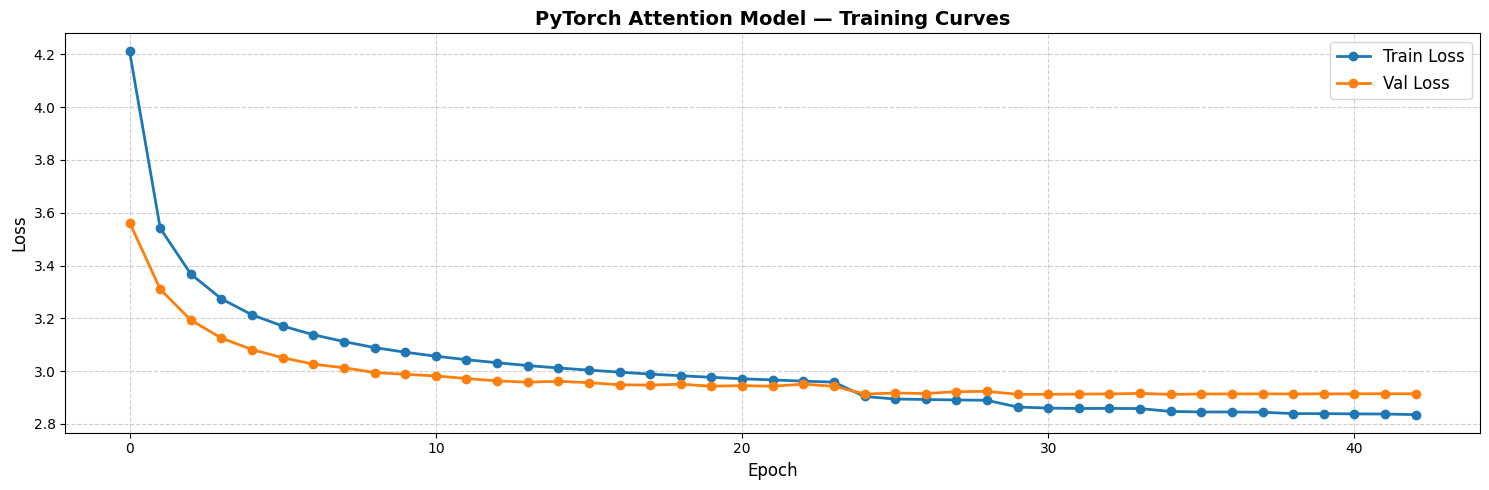

In [19]:
print('=' * 50)
print("STEP 12 — Plot Training History \n")

plt.figure(figsize=(15, 5))

# Instead of calling history.history, we just pass the Python lists we built
plt.plot(train_loss_history, label='Train Loss', marker='o', linewidth=2)
plt.plot(val_loss_history,   label='Val Loss',   marker='o', linewidth=2)

plt.title('PyTorch Attention Model — Training Curves', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)

# Senior tip: Adding a subtle grid makes diagnosing plateauing curves much easier
plt.grid(True, linestyle='--', alpha=0.6) 

plt.tight_layout()

# Save locally to your Lightning Studio
plt.savefig('attention_training_curves.png', dpi=150)
plt.show()

print('=' * 50)

In [16]:
print('=' * 50)
print("STEP 13 — Beam Search & BLEU Score Functions \n")


def generate_caption_beam(encoder, model, image_tensor, word2idx, idx2word, max_len, beam_width=5):
    # Ensure BOTH models are in eval mode (turns off dropout/batchnorm)
    encoder.eval()
    model.eval() 
    
    start_token = word2idx['<start>']
    end_token   = word2idx['<end>']
    pad_token   = word2idx['<pad>']

    # Add a batch dimension to the image and move to GPU
    # Shape becomes: (1, 3, 300, 300)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Initial beam: list of tuples (sequence_of_indices, cumulative_log_prob)
    sequences = [([start_token], 0.0)]

    with torch.no_grad():
        # THE FIX: Extract features LIVE using the encoder!
        # Output shape: (1, 100, 1536)
        feat_tensor = encoder(image_tensor)
        
        for step in range(max_len):
            all_candidates = []
            
            for seq, score in sequences:
                # If sequence already ended, keep it in the candidates
                if seq[-1] == end_token:
                    all_candidates.append((seq, score))
                    continue
                
                # Pad the current sequence to MAX_LEN for the model
                padded_seq = seq + [pad_token] * (max_len - len(seq))
                seq_tensor = torch.tensor([padded_seq], dtype=torch.long).to(device)
                
                # Forward pass through the LSTM decoder
                outputs = model(feat_tensor, seq_tensor)
                
                # Predict the NEXT word
                next_word_idx = len(seq) - 1
                next_word_logits = outputs[0, next_word_idx, :]
                
                # Convert raw logits to probabilities
                preds = F.softmax(next_word_logits, dim=-1).cpu().numpy()
                
                # Take top `beam_width` tokens
                top_indices = np.argsort(preds)[-beam_width:]
                
                for idx in top_indices:
                    new_seq = seq + [int(idx)]
                    # Add log probability to cumulative score
                    new_score = score + np.log(preds[idx] + 1e-7)
                    all_candidates.append((new_seq, new_score))
                    
            # Keep the best `beam_width` candidates
            sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_width]
            
            # If all sequences in our top beam have ended, stop early!
            if all([s[0][-1] == end_token for s in sequences]):
                break

    # Select the best sequence
    best_seq, _ = sequences[0]
    
    # Convert indices to words, removing special tokens
    words = [idx2word[idx] for idx in best_seq 
             if idx not in (pad_token, start_token, end_token)]
             
    return ' '.join(words)


# 2. ── Upgraded BLEU Evaluation (Now processes raw images) ──
def evaluate_bleu(encoder, model, val_imgs, captions_dict, image_to_path, word2idx, idx2word, max_len, num_samples=300):
    print(f"Evaluating BLEU score on {num_samples} validation images...")
    
    val_imgs_sample = list(val_imgs)[:num_samples]
    
    references = []
    hypotheses = []
    
    # We must define the exact same transform used in the Training Dataset
    transform = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # We use tqdm to show a progress bar since beam search takes time
    for img_id in tqdm(val_imgs_sample, desc="Calculating BLEU"):
        
        # 1. THE FIX: Load the raw image from disk live
        img_path = image_to_path[img_id]
        image = Image.open(img_path).convert('RGB')
        image_tensor = transform(image)
        
        # 2. Generate prediction (Notice we pass the 'encoder' now too!)
        generated = generate_caption_beam(encoder, model, image_tensor, word2idx, idx2word, max_len, beam_width=3)
        hyp = generated.split()
        
        # 3. Get actual references
        refs = []
        for cap in captions_dict[img_id]:
            words = [w for w in cap.split() if w not in ['<start>', '<end>', '<pad>']]
            refs.append(words)
            
        hypotheses.append(hyp)
        references.append(refs)

    smooth = SmoothingFunction().method1
    b1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smooth)
    b2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
    b3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
    b4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
    
    print(f"\nFinal BLEU Scores — B1: {b1:.4f} | B2: {b2:.4f} | B3: {b3:.4f} | B4: {b4:.4f}")
    return b1, b2, b3, b4

print('=' * 50)

STEP 13 — Beam Search & BLEU Score Functions 



In [17]:
print('=' * 50)
print("STEP 14 — Load Weights & BLEU Function \n")

# 1. Load the Best Weights
# We instantiate the model (it should already exist in memory from Cell 10)
# and load the weights we saved during the training loop.
print("Loading best model weights...")
model.load_state_dict(torch.load('best_model.pth', weights_only=True))
encoder.load_state_dict(torch.load('best_encoder.pth', weights_only=True))
model.eval()
encoder.eval()
print("Model loaded and set to Eval mode ✓")


print("Starting BLEU Evaluation on Test Set...")



b1, b2, b3, b4 = evaluate_bleu(
    encoder, model, list(test_imgs),
    captions_dict, image_to_path,
    word2idx, idx2word, MAX_LEN, num_samples=300
)

# Print the captured scores explicitly
print("\n--- Captured Evaluation Results ---")
print(f"BLEU-1 (1-gram): {b1:.4f}")
print(f"BLEU-2 (2-gram): {b2:.4f}")
print(f"BLEU-3 (3-gram): {b3:.4f}")
print(f"BLEU-4 (4-gram): {b4:.4f}")

print('=' * 50)

STEP 14 — Load Weights & BLEU Function 

Loading best model weights...
Model loaded and set to Eval mode ✓
Starting BLEU Evaluation on Test Set...
Evaluating BLEU score on 300 validation images...


Calculating BLEU: 100%|██████████| 300/300 [01:32<00:00,  3.23it/s]


Final BLEU Scores — B1: 0.6954 | B2: 0.5211 | B3: 0.3791 | B4: 0.2663

--- Captured Evaluation Results ---
BLEU-1 (1-gram): 0.6954
BLEU-2 (2-gram): 0.5211
BLEU-3 (3-gram): 0.3791
BLEU-4 (4-gram): 0.2663


STEP 15 — Visual Evaluation 



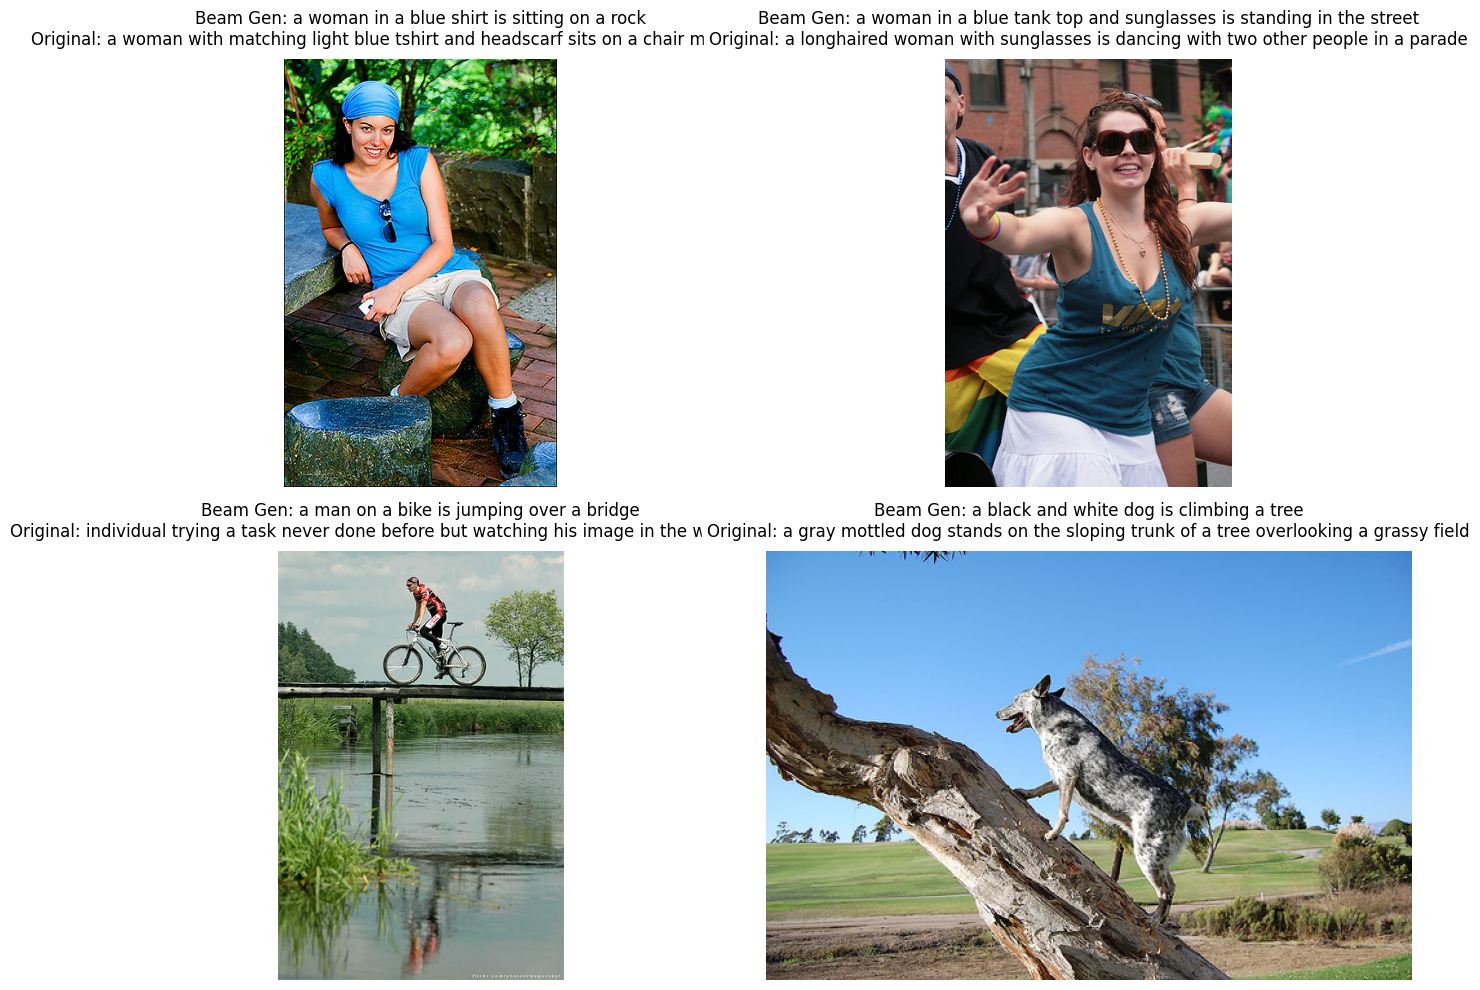

In [ ]:
print('=' * 50)
print("STEP 15 — Visual Evaluation \n")

# No more test_feats.npy! We just need the image IDs.
test_imgs_list = list(test_imgs)

# Pick 4 random test images
sample_ids = random.sample(test_imgs_list, 4)

# Exact same transform used in training
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create a nice, large figure for our 2x2 grid
plt.figure(figsize=(15, 10))

for i, img_id in enumerate(sample_ids):
    # 1. Load and transform the raw image
    img_path = image_to_path[img_id]
    image = Image.open(img_path).convert('RGB')
    image_tensor = transform(image)
    
    # 2. Generate caption with our PyTorch beam search (passing encoder live!)
    generated = generate_caption_beam(
        encoder, model, image_tensor, word2idx, idx2word, MAX_LEN, beam_width=5
    )

    # 3. Get reference captions (cleaned, without <start>/<end>)
    refs = []
    for cap in captions_dict[img_id]:
        words = [w for w in cap.split() if w not in ['<start>', '<end>']]
        refs.append(' '.join(words))

    # 4. Plot the image
    plt.subplot(2, 2, i+1)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
    
    # Text wrapping for cleaner display
    title_text = f"Beam Gen: {generated}\nOriginal: {refs[0]}"
    plt.title(title_text, fontsize=12, pad=10, backgroundcolor='white')

plt.tight_layout()
plt.savefig('final_predictions.png', dpi=150)
plt.show()

# ── Optional: Run the BLEU evaluation ──
# Notice the updated signature: we pass the encoder and image_to_path now!
# evaluate_bleu(encoder, model, test_imgs_list, captions_dict, image_to_path, word2idx, idx2word, MAX_LEN)

print('=' * 50)